In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [3]:
df=pd.read_csv('heart_disease_uci.csv')
df.drop('id',axis=1,inplace=True)

In [43]:
df_copy=pd.read_csv('heart_disease_uci.csv')

In [11]:
df.isnull().sum()

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

In [6]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0


In [5]:
df.drop(columns=['ca','thal'],inplace=True)

In [62]:
df['exang'].fillna(df['exang'].mode()[0], inplace=True)

C:\Users\krish\AppData\Local\Temp\ipykernel_16904\318069990.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['exang'].fillna(df['exang'].mode()[0], inplace=True)
C:\Users\krish\AppData\Local\Temp\ipykernel_16904\318069990.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'].fillna(df['exang'].m

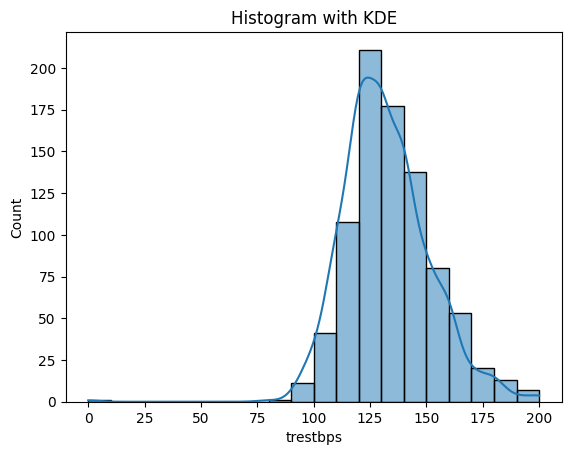

In [11]:
sns.histplot(df["trestbps"], kde=True, bins=20)
plt.title("Histogram with KDE")
plt.show()

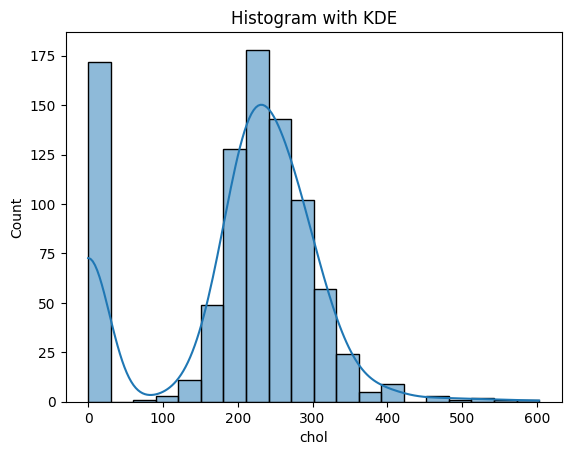

In [12]:
sns.histplot(df["chol"], kde=True, bins=20)
plt.title("Histogram with KDE")
plt.show()

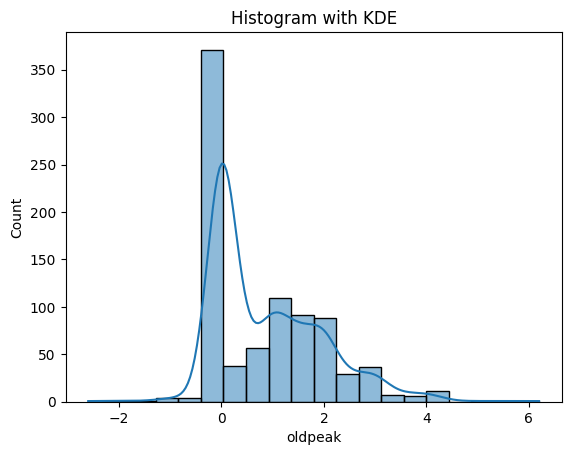

In [13]:
sns.histplot(df["oldpeak"], kde=True, bins=20)
plt.title("Histogram with KDE")
plt.show()

In [7]:
df['trestbps'].fillna(df['trestbps'].mean(), inplace=True)
df['chol'].fillna(df['chol'].median(), inplace=True)
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)
df['thalch'].fillna(df['thalch'].mean(), inplace=True)


C:\Users\krish\AppData\Local\Temp\ipykernel_19012\1149915541.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['trestbps'].fillna(df['trestbps'].mean(), inplace=True)
C:\Users\krish\AppData\Local\Temp\ipykernel_19012\1149915541.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [10]:
for col in ['fbs','exang','slope']:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['restecg'].fillna(df['restecg'].mode()[0], inplace=True)

C:\Users\krish\AppData\Local\Temp\ipykernel_19012\3736037329.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [24]:
df.isnull().sum()

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

In [25]:
df.shape

(920, 13)

In [26]:
df.describe(include='object')

,sex,dataset,cp,restecg,slope
count,920,920,920,920,920
unique,2,4,4,3,3
top,Male,Cleveland,asymptomatic,normal,flat
freq,726,304,496,553,654


In [27]:
df['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [12]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope']

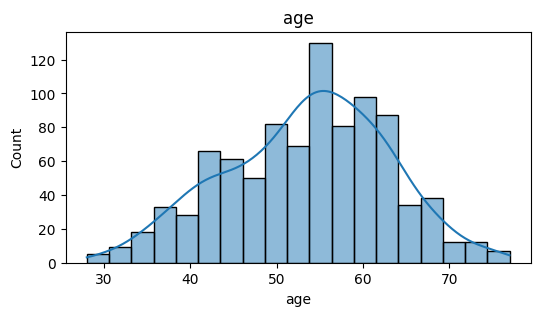

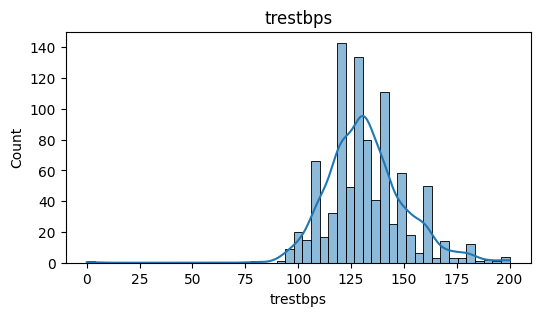

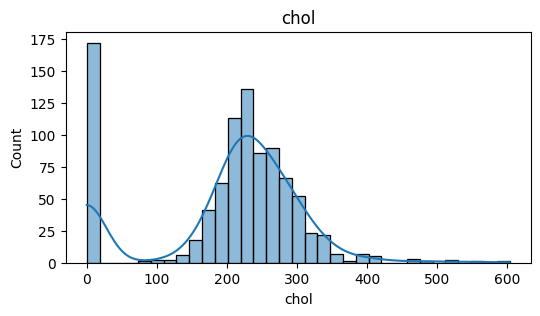

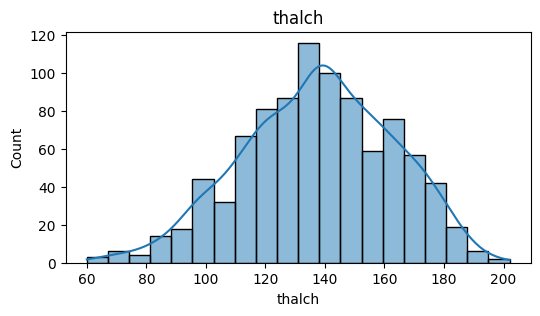

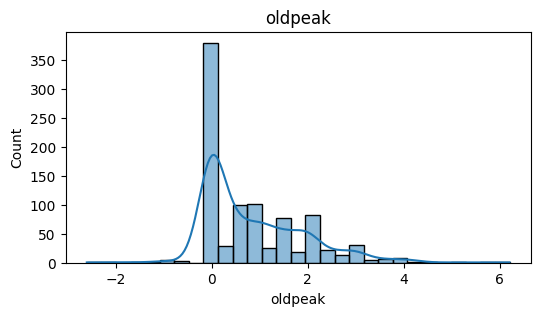

In [13]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

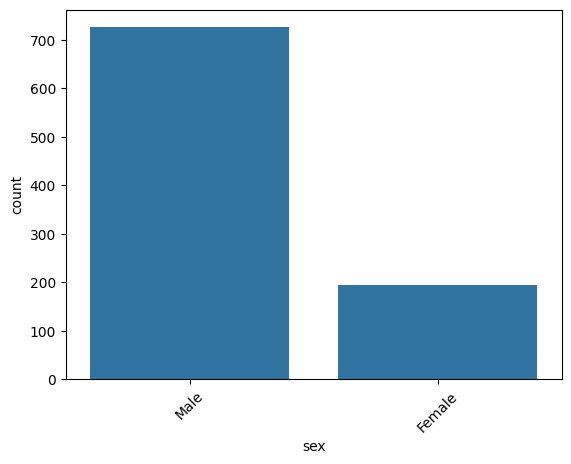

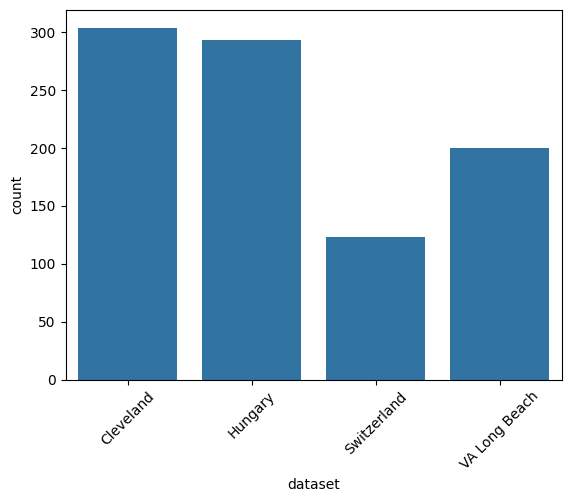

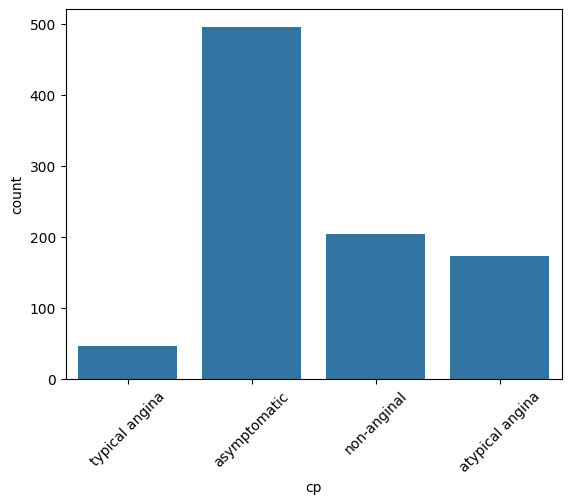

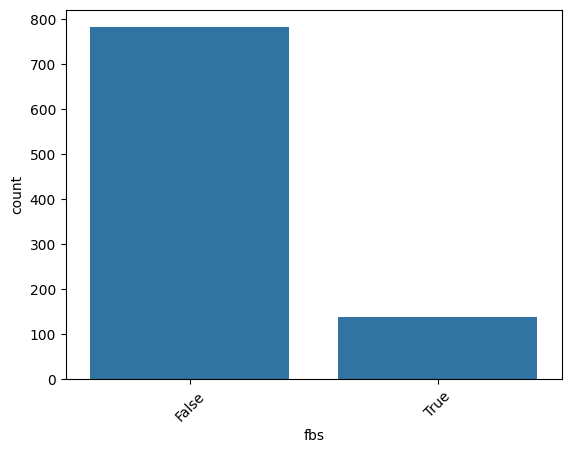

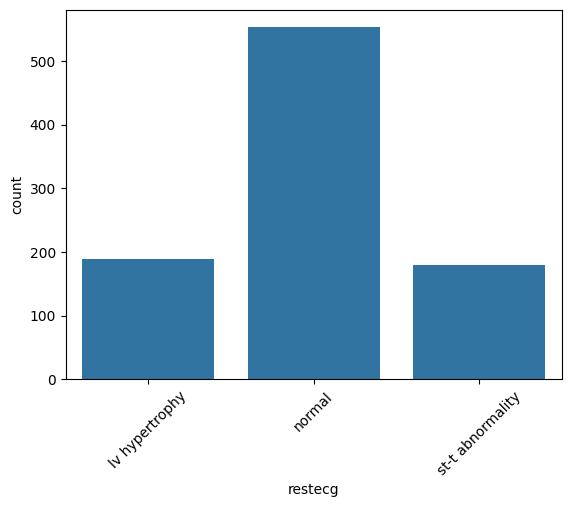

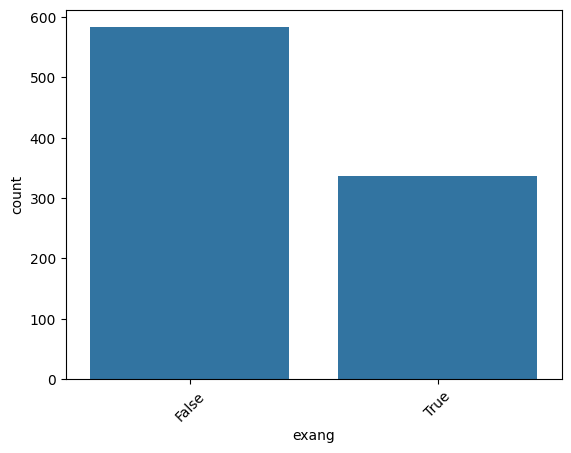

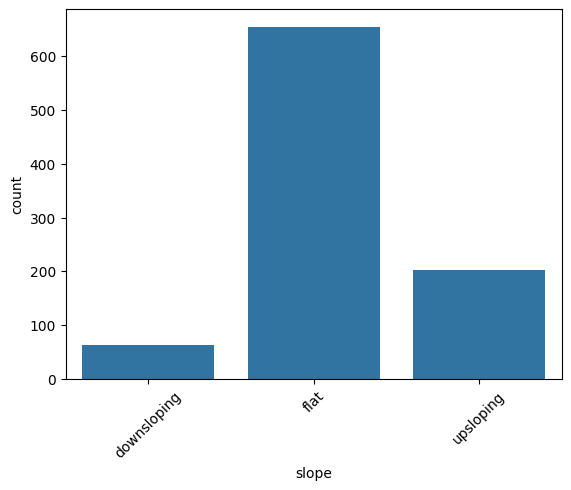

In [32]:
for col in cat_cols:
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.show()

## Outlier detection

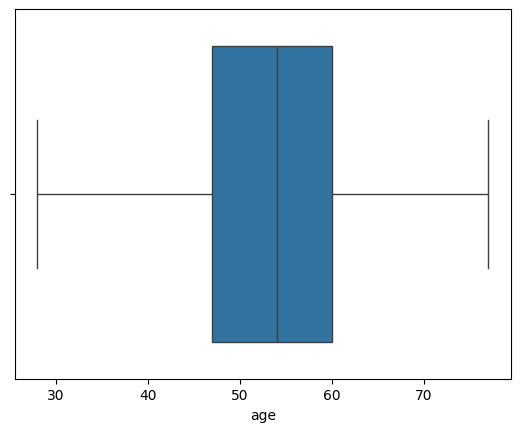

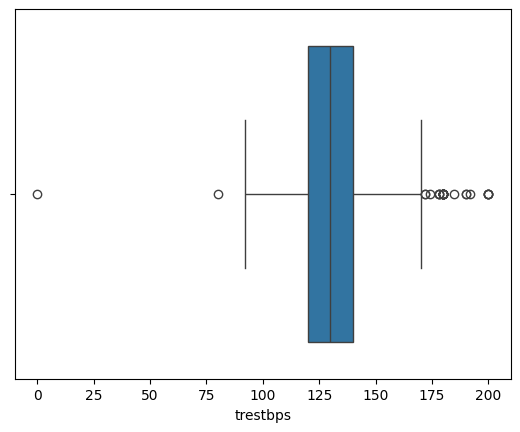

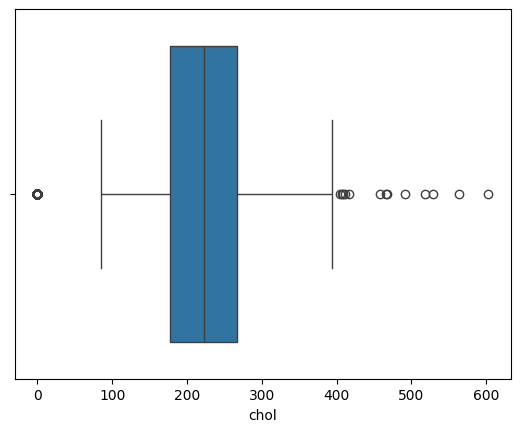

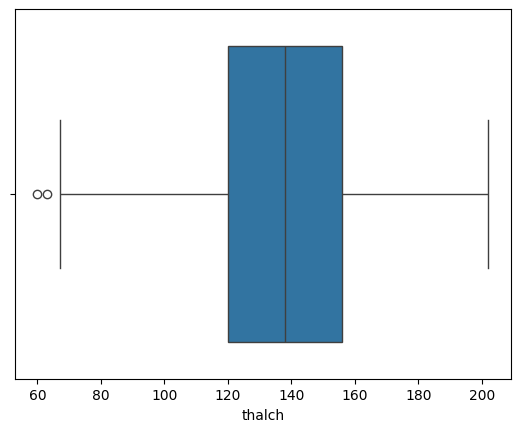

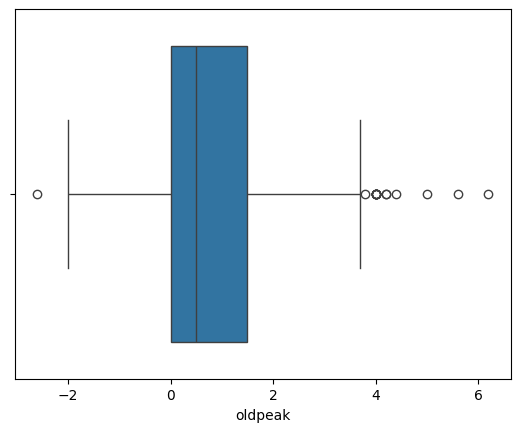

In [33]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

<Axes: xlabel='cp', ylabel='count'>

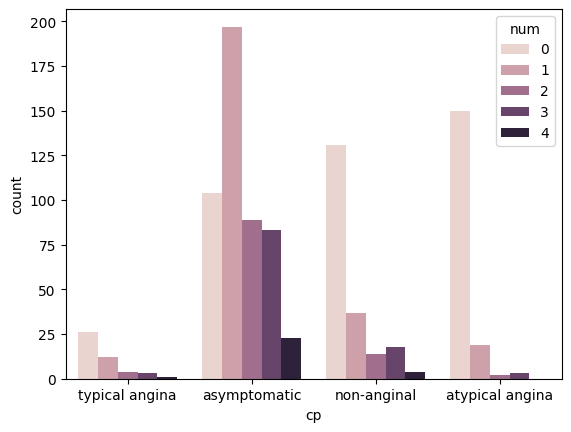

In [34]:
sns.countplot(x='cp', hue='num', data=df)

<Axes: xlabel='num', ylabel='age'>

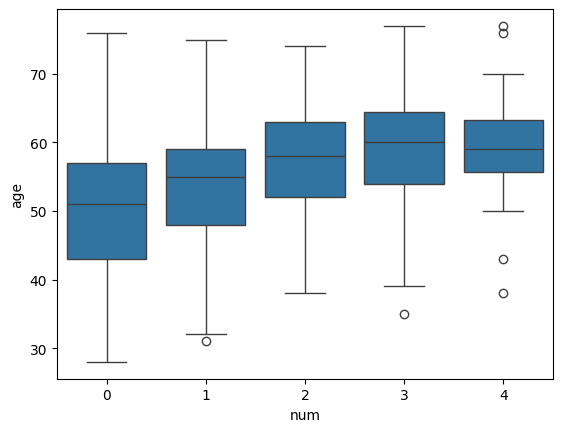

In [37]:
sns.boxplot(x='num', y='age', data=df)


<Axes: xlabel='num', ylabel='oldpeak'>

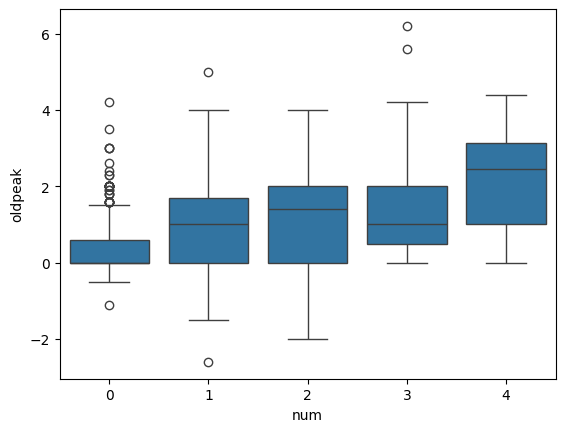

In [38]:
sns.boxplot(x='num', y='oldpeak', data=df)

## Encoding catagorical features

In [15]:
df['sex'] = df['sex'].map({'Male':1, 'Female':0})

In [17]:
df.drop(columns=['dataset'], inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    int64  
 2   cp        920 non-null    object 
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    bool   
 6   restecg   920 non-null    object 
 7   thalch    920 non-null    float64
 8   exang     920 non-null    bool   
 9   oldpeak   920 non-null    float64
 10  slope     920 non-null    object 
 11  num       920 non-null    int64  
dtypes: bool(2), float64(4), int64(3), object(3)
memory usage: 73.8+ KB


In [19]:
df.slope.value_counts()

slope
flat           654
upsloping      203
downsloping     63
Name: count, dtype: int64

In [20]:
df = pd.get_dummies(df, columns=['cp','restecg','slope'], drop_first=True)

In [27]:

df.head()
df.columns

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'num', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'restecg_normal', 'restecg_st-t abnormality', 'slope_flat',
       'slope_upsloping'],
      dtype='object')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   sex                       920 non-null    int64  
 2   trestbps                  920 non-null    float64
 3   chol                      920 non-null    float64
 4   fbs                       920 non-null    int64  
 5   thalch                    920 non-null    float64
 6   exang                     920 non-null    int64  
 7   oldpeak                   920 non-null    float64
 8   num                       920 non-null    int64  
 9   cp_atypical angina        920 non-null    int64  
 10  cp_non-anginal            920 non-null    int64  
 11  cp_typical angina         920 non-null    int64  
 12  restecg_normal            920 non-null    int64  
 13  restecg_st-t abnormality  920 non-null    int64  
 14  slope_flat

In [22]:
df['fbs']=df['fbs'].astype(int)

In [24]:

bool_cols = df.select_dtypes(include='bool').columns
for col in bool_cols:
    df[col] = df[col].astype(int)

In [29]:
df.num.value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [32]:
df.to_csv('heart_disease_uci_cleaned.csv', index=False)